# Thailand green coffee imports (HS 090111), total volume by year
Source: World Bank WITS. Uses the `World` row of each year (total from all partners).

In [2]:
# Google Colab only: upload the CSV. Skip this cell in Jupyter if the CSV is in the same folder.
try:
    from google.colab import files
    files.upload()   # choose thailand_coffee_imports_090111_1992_2025.csv
except ImportError:
    pass

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv("thailand_coffee_imports_2024.csv")

# Keep only the World total for each year (one row per year)
world = df[df["Partner"] == "World"][["Year", "Quantity", "Trade Value 1000USD"]].copy()
world["Volume_million_kg"] = world["Quantity"] / 1_000_000   # kg -> million kg

# Drop 2025 (may be incomplete in WITS)
world = world[world["Year"] <= 2024]

# Add missing years (1995) as NaN so the line shows a gap instead of joining across it
all_years = range(world["Year"].min(), world["Year"].max() + 1)
world = world.set_index("Year").reindex(all_years)
world.index.name = "Year"
world[["Volume_million_kg"]]

,Volume_million_kg
Year,
1992,0.006375
1993,0.025381
1994,0.019122
1995,NaN
1996,0.001073
1997,0.001467
1998,1.336590
1999,0.003709
2000,0.006891


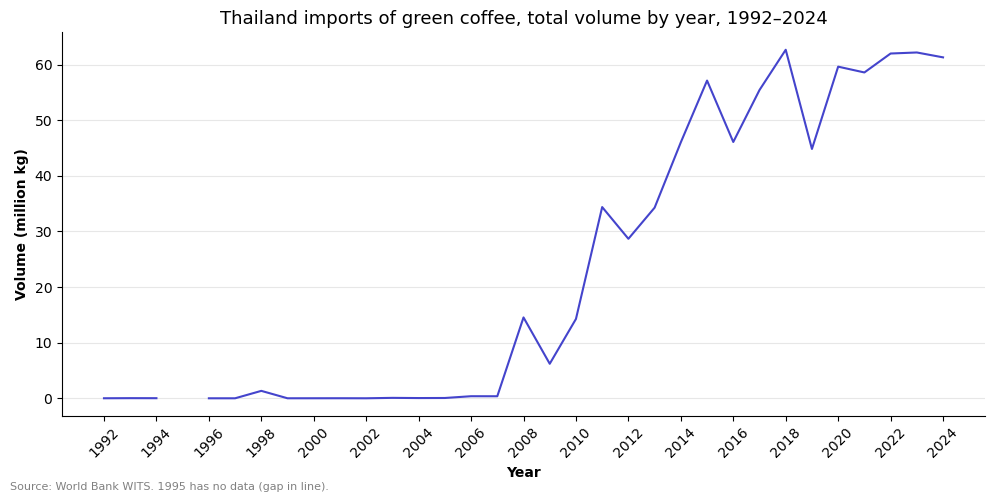

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(world.index, world["Volume_million_kg"],
        linewidth=1.5, color="#4444CC")
# Vertical dotted lines at 2009 and 2011
#for yr in [2009, 2011]:
    #ax.axvline(x=yr, color="orange", linestyle=":", linewidth=1.5)
    #ax.text(yr + 0.2, 64, str(yr), color="#444444", fontsize=9)

ax.set_title("Thailand imports of green coffee, total volume by year, 1992–2024", fontsize=13)
ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("Volume (million kg)" ,fontweight="bold" )
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(range(1992, 2025, 2))
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.01, 0.01, "Source: World Bank WITS. 1995 has no data (gap in line).", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("thailand_coffee_import_volume.png", dpi=150, bbox_inches="tight")
plt.show()

